Images shape: (615, 128, 128)
Labels shape: (615,)
Number of cats: 260
Number of dogs: 355
Decision Tree Accuracy: 0.8618
Random Forest Accuracy: 0.9350
Linear Regression Accuracy: 0.9268


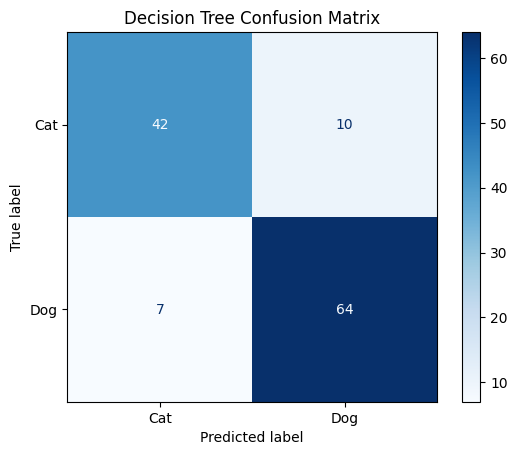

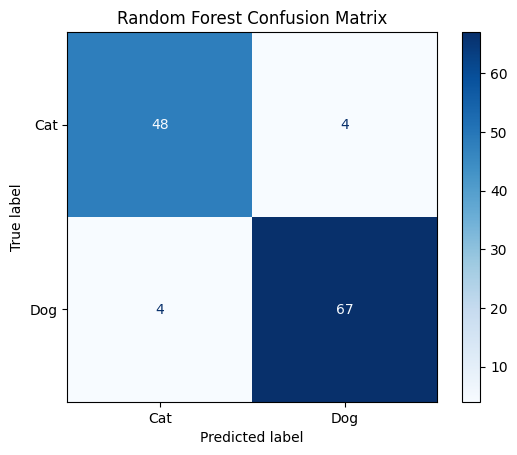

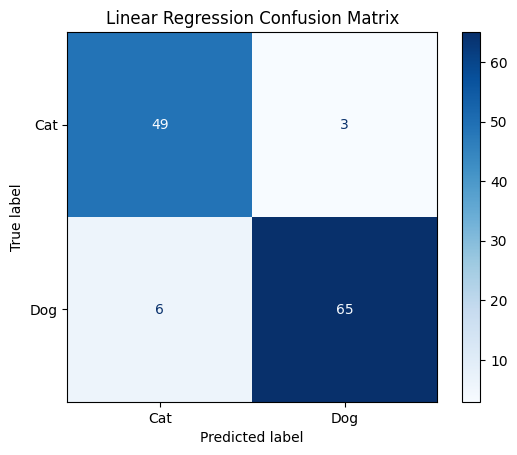

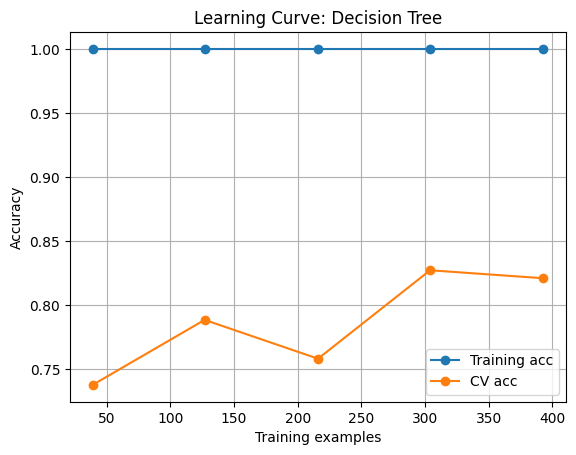

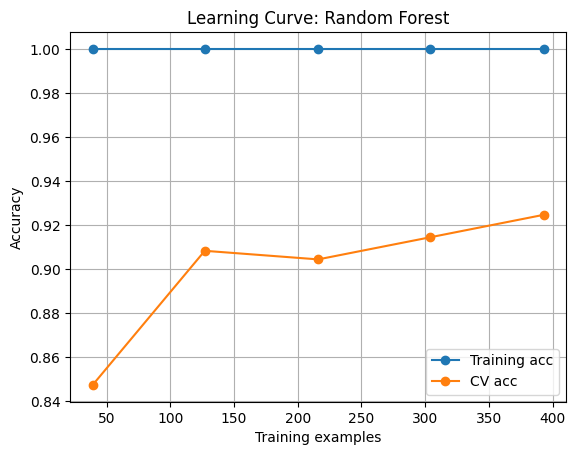

c:\Users\ALFA\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_validation.py:953: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "c:\Users\ALFA\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_validation.py", line 942, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
  File "c:\Users\ALFA\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_scorer.py", line 308, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
           ~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\ALFA\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_scorer.py", line 408, in _score
    return self._sign * self._score_func(y_true, y_pred, **scoring_kwargs)
                     

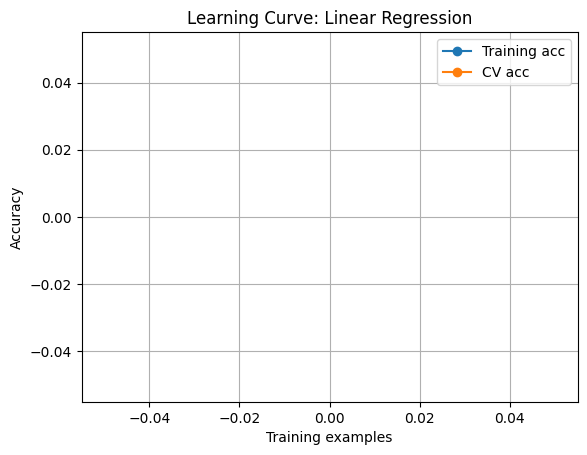

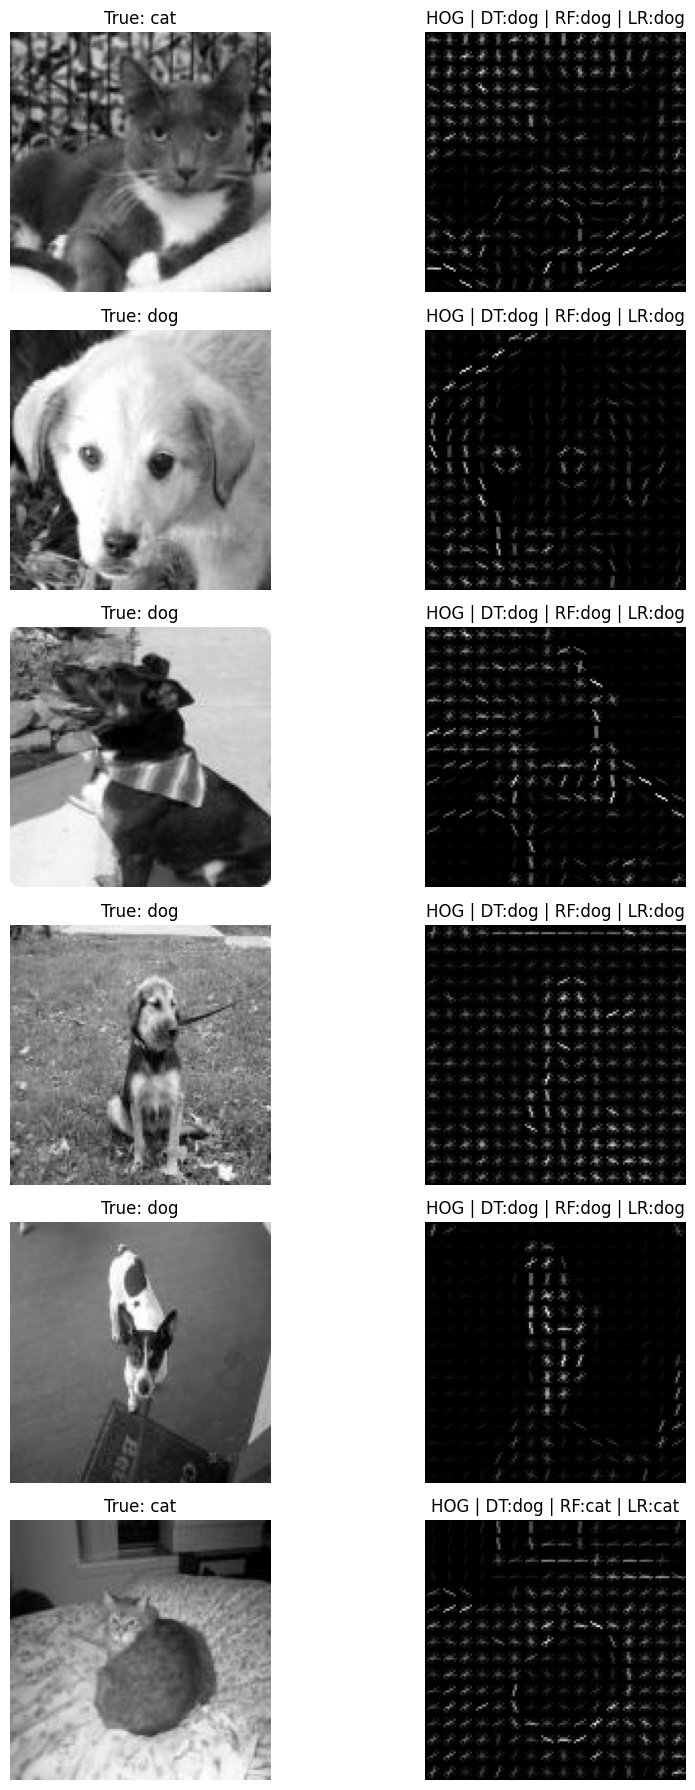

In [ ]:
import os
import numpy as np
from skimage.io import imread, imsave
from skimage.color import rgb2gray
from skimage.feature import hog
from skimage.transform import resize
from skimage import img_as_ubyte
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, learning_curve   # NEW: learning_curve
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier                   # NEW
from sklearn.linear_model import LinearRegression                     # NEW
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay   # NEW


# ----------------------------
# Load dataset
data_dir = './dataset'
images = []
labels = []

files = os.listdir(data_dir)
for file in files:
    if file.endswith('.jpg'):
        img_path = os.path.join(data_dir, file)

        # Labels: 0=cat, 1=dog
        if file.startswith('cat'):
            labels.append(0)
        elif file.startswith('dog'):
            labels.append(1)
        else:
            continue

        # Read + preprocess
        img = imread(img_path)
        if img.ndim == 3:
            img = rgb2gray(img)
        img_resized = resize(img, (128, 128), anti_aliasing=True)
        images.append(img_resized)

images = np.array(images)
labels = np.array(labels)

print('Images shape:', images.shape)
print('Labels shape:', labels.shape)
print(f'Number of cats: {np.sum(labels == 0)}')
print(f'Number of dogs: {np.sum(labels == 1)}')


# ----------------------------
# Extract HOG features
def extract_hog_features(images, visualize=False,
                         pixels_per_cell=(8, 8),
                         cells_per_block=(2, 2),
                         orientations=9):
    hog_features = []
    hog_images = []
    for img in images:
        if visualize:
            features, hog_image = hog(img,
                                      orientations=orientations,
                                      pixels_per_cell=pixels_per_cell,
                                      cells_per_block=cells_per_block,
                                      visualize=True,
                                      block_norm='L2-Hys')
            hog_features.append(features)
            hog_images.append(hog_image)
        else:
            features = hog(img,
                           orientations=orientations,
                           pixels_per_cell=pixels_per_cell,
                           cells_per_block=cells_per_block,
                           visualize=False,
                           block_norm='L2-Hys')
            hog_features.append(features)

    hog_features = np.array(hog_features)
    hog_images = np.array(hog_images) if visualize else None
    return hog_features, hog_images


# ----------------------------
# Split dataset
def split_dataset(images, labels, test_size=0.2):
    idx_train, idx_test = train_test_split(
        np.arange(len(images)),
        test_size=test_size,
        stratify=labels,
        random_state=42
    )
    y_train = labels[idx_train]
    y_test = labels[idx_test]
    return idx_train, idx_test, y_train, y_test


# ----------------------------
#TRAIN MODELS

#DecisionTree
def train_decision_tree(X_train, y_train,
                        max_depth=20,
                        min_samples_split=5,
                        min_samples_leaf=2):
    clf = DecisionTreeClassifier(max_depth=max_depth,
                                 min_samples_split=min_samples_split,
                                 min_samples_leaf=min_samples_leaf,
                                 random_state=42)
    clf.fit(X_train, y_train)
    return clf


#RandomForest
def train_random_forest(X_train, y_train,
                        n_estimators=100,
                        max_depth=20):
    clf = RandomForestClassifier(n_estimators=n_estimators,
                                 max_depth=max_depth,
                                 random_state=42)
    clf.fit(X_train, y_train)
    return clf


#LinearRegression (with thresholding)
def train_linear_regression(X_train, y_train):
    clf = LinearRegression()
    clf.fit(X_train, y_train)
    return clf


def lr_predict_to_binary(model, X, threshold=0.5):
    y_cont = model.predict(X)
    return (y_cont >= threshold).astype(int), y_cont


# ----------------------------
# Evaluate
def evaluate_model(clf, X_test, y_test):
    y_pred = clf.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    return accuracy, y_pred


#confusion matrix
def plot_confusion(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=['Cat', 'Dog'])
    disp.plot(cmap=plt.cm.Blues, values_format='d')
    plt.title(title)
    plt.show()


#learning curve
def plot_learning_curve(estimator, X, y, title, cv=5,
                        train_sizes=np.linspace(0.1, 1.0, 5)):
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv,
        train_sizes=train_sizes,
        scoring='accuracy'
    )
    train_mean = np.mean(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)

    plt.figure()
    plt.plot(train_sizes, train_mean, 'o-', label='Training acc')
    plt.plot(train_sizes, test_mean, 'o-', label='CV acc')
    plt.title(f'Learning Curve: {title}')
    plt.xlabel('Training examples')
    plt.ylabel('Accuracy')
    plt.legend(loc='best')
    plt.grid(True)
    plt.show()


# ----------------------------
# Main pipeline
hog_features, hog_images = extract_hog_features(images, visualize=True)
idx_train, idx_test, y_train, y_test = split_dataset(images, labels, test_size=0.2)
X_train, X_test = hog_features[idx_train], hog_features[idx_test]

# Train models
dt = train_decision_tree(X_train, y_train)
rf = train_random_forest(X_train, y_train)          # NEW
lr = train_linear_regression(X_train, y_train)      # NEW

# Predictions
dt_acc, dt_pred = evaluate_model(dt, X_test, y_test)
rf_acc, rf_pred = evaluate_model(rf, X_test, y_test)                # NEW
lr_pred, lr_cont = lr_predict_to_binary(lr, X_test, threshold=0.5)  # NEW
lr_acc = accuracy_score(y_test, lr_pred)                            # NEW

print(f"Decision Tree Accuracy: {dt_acc:.4f}")
print(f"Random Forest Accuracy: {rf_acc:.4f}")      # NEW
print(f"Linear Regression Accuracy: {lr_acc:.4f}")  # NEW

# Confusion matrices
plot_confusion(y_test, dt_pred, "Decision Tree Confusion Matrix")   # NEW
plot_confusion(y_test, rf_pred, "Random Forest Confusion Matrix")   # NEW
plot_confusion(y_test, lr_pred, "Linear Regression Confusion Matrix")   # NEW

# Learning curves
plot_learning_curve(DecisionTreeClassifier(max_depth=20, random_state=42),
                    X_train, y_train, "Decision Tree")              # NEW
plot_learning_curve(RandomForestClassifier(n_estimators=100, max_depth=20, random_state=42),
                    X_train, y_train, "Random Forest")              # NEW
# plot_learning_curve(LinearRegression(), X_train, y_train, "Linear Regression")  # NEW
plot_learning_curve(LinearRegression(), X_train, y_train, "Linear Regression")

# ----------------------------
# Visualize samples (original + HOG + predictions)
classes = ['cat', 'dog']
sample_indices = idx_test[:6]   # show 6 samples max
fig, axes = plt.subplots(len(sample_indices), 2,
                         figsize=(10, 3 * len(sample_indices)))
for i, idx in enumerate(sample_indices):
    true_lbl = y_test[np.where(idx_test == idx)[0][0]]
    dt_p = dt_pred[np.where(idx_test == idx)[0][0]]
    rf_p = rf_pred[np.where(idx_test == idx)[0][0]]
    lr_p = lr_pred[np.where(idx_test == idx)[0][0]]


    # Original
    ax = axes[i, 0]
    ax.imshow(images[idx], cmap='gray')
    ax.set_title(f"True: {classes[true_lbl]}")
    ax.axis('off')

    # HOG
    ax = axes[i, 1]
    ax.imshow(hog_images[idx], cmap='gray')
    ax.set_title(f"HOG | DT:{classes[dt_p]} | RF:{classes[rf_p]} | LR:{classes[lr_p]}")
    ax.axis('off')

plt.tight_layout()
plt.show()


